In [ ]:
# ToxLens | 04 — Explainability & Gradio Interface
### Atomic-level toxicity interpretation + live prediction tool
### Primary model: XGBoost (AUC 0.8566) | GNN used for atom attribution

In [1]:
#Cell — Rebuild processed data
from google.colab import files
files.upload()  # upload kaggle.json

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d epicskills/tox21-dataset --unzip -p /content/tox21/ -q
!kaggle datasets download -d basu369victor/zinc250k --unzip -p /content/zinc250k/ -q

!pip install rdkit deepchem imbalanced-learn xgboost shap gradio py3Dmol mlflow optuna -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, pickle
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, QED, Draw
from rdkit.Chem.inchi import MolToInchiKey
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, HTML
import shap

sns.set_theme(style="whitegrid", palette="muted")

tox21_df = pd.read_csv('/content/tox21/tox21.csv')
zinc_df  = pd.read_csv('/content/zinc250k/250k_rndm_zinc_drugs_clean_3.csv')
zinc_df['smiles'] = zinc_df['smiles'].str.strip()

def is_valid_smiles(smi):
    try: return Chem.MolFromSmiles(str(smi)) is not None
    except: return False

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return [np.nan] * 8
    return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol),
            Descriptors.TPSA(mol), rdMolDescriptors.CalcNumRings(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol), Descriptors.FractionCSP3(mol)]

def get_inchikey(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        return MolToInchiKey(mol) if mol else None
    except: return None

def smiles_to_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return np.zeros(n_bits)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))

tox21_df = tox21_df[tox21_df['smiles'].apply(is_valid_smiles)].reset_index(drop=True)
desc_cols = ['MolWt','LogP','HBD','HBA','TPSA','NumRings','AromaticRings','FractionCSP3']
desc_df   = pd.DataFrame(tox21_df['smiles'].apply(compute_descriptors).tolist(), columns=desc_cols)
tox21_df  = pd.concat([tox21_df, desc_df], axis=1)
tox21_df['inchikey'] = tox21_df['smiles'].apply(get_inchikey)
zinc_df['inchikey']  = zinc_df['smiles'].apply(get_inchikey)
zinc_features        = zinc_df[['inchikey','logP','qed','SAS']].dropna(subset=['inchikey'])
tox21_df             = tox21_df.merge(zinc_features, on='inchikey', how='left')
mask = tox21_df['qed'].isna()
tox21_df.loc[mask, 'logP'] = tox21_df.loc[mask, 'smiles'].apply(
    lambda s: Descriptors.MolLogP(Chem.MolFromSmiles(str(s))) if Chem.MolFromSmiles(str(s)) else np.nan)
tox21_df.loc[mask, 'qed']  = tox21_df.loc[mask, 'smiles'].apply(
    lambda s: QED.qed(Chem.MolFromSmiles(str(s))) if Chem.MolFromSmiles(str(s)) else np.nan)
fp_matrix = np.vstack(tox21_df['smiles'].apply(smiles_to_fp).values)

assay_cols = ['NR-AR','NR-AR-LBD','NR-AhR','NR-Aromatase',
              'NR-ER','NR-ER-LBD','NR-PPAR-gamma',
              'SR-ARE','SR-ATAD5','SR-HSE','SR-MMP','SR-p53']
all_desc_cols = desc_cols + ['qed']

print(f"Ready. Compounds: {len(tox21_df)}")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/epicskills/tox21-dataset
License(s): DbCL-1.0
Dataset URL: https://www.kaggle.com/datasets/basu369victor/zinc250k
License(s): DbCL-1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 10.2 MB/s eta

Streaming output truncated to the last 5000 lines.
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:17:37] DEPRECATION WARNING: please use MorganGenerator
[15:1

Ready. Compounds: 7823


## 1. Retrain XGBoost Models
Retraining all 12 assay models with best parameters from notebook 02.
Required since Colab runtime was reset.

In [2]:
#Cell — Retrain XGBoost
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

desc_matrix = tox21_df[all_desc_cols].fillna(tox21_df[all_desc_cols].median()).values
X = np.hstack([fp_matrix, desc_matrix])

models  = {}
results = {}

for assay in assay_cols:
    mask      = tox21_df[assay].notna()
    X_task    = X[mask]
    y_task    = tox21_df.loc[mask, assay].astype(int).values
    X_train, X_test, y_train, y_test = train_test_split(
        X_task, y_task, test_size=0.2, random_state=42, stratify=y_task)
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    spw = neg / pos if pos > 0 else 1.0

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 400),
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight': spw,
            'eval_metric':      'auc',
            'random_state':     42,
            'tree_method':      'hist',
            'device':           'cuda',
        }
        m = XGBClassifier(**params)
        m.fit(X_train, y_train, verbose=False)
        return roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)
    best = study.best_params
    best.update({'scale_pos_weight': spw, 'eval_metric': 'auc',
                 'random_state': 42, 'tree_method': 'hist', 'device': 'cuda'})

    final = XGBClassifier(**best)
    final.fit(X_train, y_train, verbose=False)
    auc = roc_auc_score(y_test, final.predict_proba(X_test)[:, 1])
    models[assay]  = final
    results[assay] = auc
    print(f"  {assay:<20} AUC: {auc:.4f}")

print(f"\nMean AUC: {np.mean(list(results.values())):.4f}")

  NR-AR                AUC: 0.7765
  NR-AR-LBD            AUC: 0.8889
  NR-AhR               AUC: 0.9020
  NR-Aromatase         AUC: 0.8846
  NR-ER                AUC: 0.7286
  NR-ER-LBD            AUC: 0.8590
  NR-PPAR-gamma        AUC: 0.8650
  SR-ARE               AUC: 0.8550
  SR-ATAD5             AUC: 0.8866
  SR-HSE               AUC: 0.8108
  SR-MMP               AUC: 0.9273
  SR-p53               AUC: 0.9024

Mean AUC: 0.8572


## 2. SHAP Global Feature Importance
Identifying which molecular properties drive toxicity predictions
across all 12 assays.

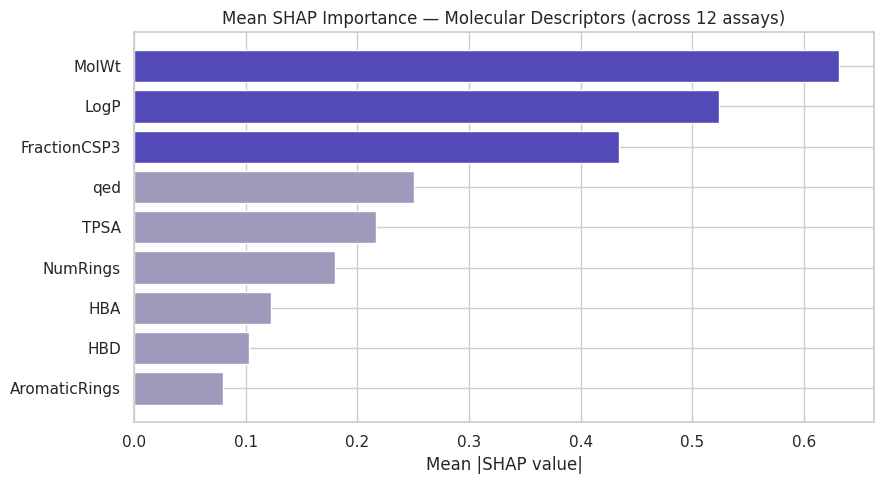

Top 3 most important descriptors:
  1. MolWt: 0.63138
  2. LogP: 0.52431
  3. FractionCSP3: 0.43428


In [3]:
#Cell — SHAP per assay
feat_names = [f'FP_{i}' for i in range(2048)] + all_desc_cols
shap_desc_importance = {}

for assay in assay_cols:
    mask = tox21_df[assay].notna()
    X_task = X[mask]
    y_task = tox21_df.loc[mask, assay].astype(int).values
    _, X_test, _, _ = train_test_split(
        X_task, y_task, test_size=0.2, random_state=42, stratify=y_task)

    explainer   = shap.TreeExplainer(models[assay])
    shap_vals   = explainer.shap_values(X_test[:150])
    desc_shap   = np.abs(shap_vals[:, 2048:]).mean(axis=0)
    shap_desc_importance[assay] = dict(zip(all_desc_cols, desc_shap))

# Aggregate across assays
importance_df = pd.DataFrame(shap_desc_importance).T
mean_importance = importance_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#534AB7' if i < 3 else '#9F9ABB' for i in range(len(mean_importance))]
ax.barh(mean_importance.index[::-1], mean_importance.values[::-1], color=colors[::-1])
ax.set_title('Mean SHAP Importance — Molecular Descriptors (across 12 assays)',
             fontsize=12, fontweight='500')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('/content/shap_global.png', dpi=150)
plt.show()
print("Top 3 most important descriptors:")
for i, (feat, val) in enumerate(mean_importance.head(3).items()):
    print(f"  {i+1}. {feat}: {val:.5f}")

## 3. Atom-Level Toxicity Attribution
Using Morgan fingerprint bit contributions to highlight which atoms
in a molecule drive toxicity predictions — the key visual differentiator.

[16:05:01] DEPRECATION WARNING: please use MorganGenerator
[16:05:01] DEPRECATION WARNING: please use MorganGenerator


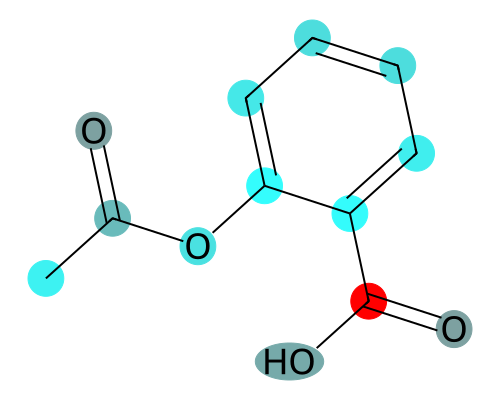

Assay: SR-MMP | Aspirin atom attribution rendered.
Red atoms = high toxicity contribution | White = low


In [5]:
from rdkit.Chem import rdMolDescriptors
from IPython.display import SVG

def get_atom_weights(smiles, model, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None, None

    # Get bit info
    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(
        mol, radius, nBits=n_bits, bitInfo=bit_info)

    # Build FULL feature vector (same as training)
    fp_arr  = smiles_to_fp(smiles)
    dsc     = compute_descriptors(smiles)
    qed_val = QED.qed(mol)
    dsc_arr = np.nan_to_num(np.array(dsc + [qed_val]), nan=0.0)
    x_full  = np.hstack([fp_arr, dsc_arr]).reshape(1, -1)

    # SHAP on full feature vector
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(x_full)

    # Only use FP portion for atom attribution
    fp_shap = shap_vals[0, :2048]

    # Map bit SHAP values back to atoms
    atom_weights = np.zeros(mol.GetNumAtoms())
    for bit, atom_list in bit_info.items():
        for atom_idx, _ in atom_list:
            atom_weights[atom_idx] += abs(fp_shap[bit])

    if atom_weights.max() > 0:
        atom_weights /= atom_weights.max()

    return mol, atom_weights

def draw_highlighted_molecule(smiles, model, assay_name, size=(500, 400)):
    """
    Draw molecule with atoms colored by toxicity contribution.
    Red = high contribution, white = low.
    """
    mol, weights = get_atom_weights(smiles, model)
    if mol is None:
        return None

    atom_colors = {}
    highlight_atoms = []
    for i, w in enumerate(weights):
        r = min(1.0, 0.2 + 0.8 * w)
        g = max(0.0, 1.0 - w)
        b = max(0.0, 1.0 - w)
        atom_colors[i]  = (r, g, b)
        highlight_atoms.append(i)

    drawer = rdMolDraw2D.MolDraw2DSVG(size[0], size[1])
    drawer.drawOptions().addAtomIndices = False
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_colors,
        highlightBonds=[],
    )
    drawer.FinishDrawing()
    return drawer.GetDrawingText()


# Test on a known toxic compound — Aspirin SMILES
test_smiles  = 'CC(=O)Oc1ccccc1C(=O)O'
best_assay   = max(results, key=results.get)
svg_output   = draw_highlighted_molecule(test_smiles, models[best_assay], best_assay)

if svg_output:
    display(SVG(svg_output))
    with open('/content/aspirin_highlighted.svg', 'w') as f:
        f.write(svg_output)
    print(f"Assay: {best_assay} | Aspirin atom attribution rendered.")
    print("Red atoms = high toxicity contribution | White = low")

## 4. ToxLens Gradio Interface
Live prediction tool — input any SMILES string and get:
- Toxicity probability across all 12 assays
- Highlighted molecule showing which atoms drive toxicity
- Key molecular property summary

In [7]:
!pip install cairosvg -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.7 MB/s eta 0:00:00


In [11]:
import gradio as gr
import base64, io
from PIL import Image

def predict_toxicity(smiles_input):
    smiles = smiles_input.strip()
    mol    = Chem.MolFromSmiles(smiles)

    if mol is None:
        return "❌ Invalid SMILES string. Please check your input.", None, None

    fp      = smiles_to_fp(smiles)
    dsc     = compute_descriptors(smiles)
    qed_val = QED.qed(mol)
    dsc_arr = np.nan_to_num(np.array(dsc + [qed_val]), nan=0.0)
    x       = np.hstack([fp, dsc_arr]).reshape(1, -1)

    rows = []
    for assay in assay_cols:
        prob  = models[assay].predict_proba(x)[0][1]
        risk  = "🔴 High" if prob > 0.5 else "🟡 Moderate" if prob > 0.3 else "🟢 Low"
        bar   = "█" * int(prob * 20) + "░" * (20 - int(prob * 20))
        rows.append({
            'Assay': assay,
            'Probability': round(prob, 4),
            'Risk Level': risk,
            'Confidence Bar': bar
        })
    pred_df = pd.DataFrame(rows)

    best    = max(results, key=results.get)
    svg     = draw_highlighted_molecule(smiles, models[best], best)
    mol_img = None
    if svg:
        from cairosvg import svg2png
        png_bytes = svg2png(bytestring=svg.encode())
        mol_img   = Image.open(io.BytesIO(png_bytes))

    mw      = Descriptors.MolWt(mol)
    logp    = Descriptors.MolLogP(mol)
    hbd     = Descriptors.NumHDonors(mol)
    hba     = Descriptors.NumHAcceptors(mol)
    tpsa    = Descriptors.TPSA(mol)
    arom    = rdMolDescriptors.CalcNumAromaticRings(mol)
    lipinski = "✅ Pass" if mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10 else "❌ Fail"

    high_risk  = sum(1 for r in rows if "High"     in r['Risk Level'])
    mod_risk   = sum(1 for r in rows if "Moderate" in r['Risk Level'])
    low_risk   = sum(1 for r in rows if "Low"      in r['Risk Level'])
    mean_prob  = np.mean([r['Probability'] for r in rows])
    overall    = "HIGH RISK" if high_risk >= 4 else "MODERATE RISK" if high_risk >= 1 or mod_risk >= 4 else "LOW RISK"

    props = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 4px;">

  <div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
              border-radius: 12px; padding: 20px; margin-bottom: 16px;">
    <div style="color: #a0c4ff; font-size: 11px; letter-spacing: 2px; text-transform: uppercase; margin-bottom: 6px;">
      Overall Assessment
    </div>
    <div style="color: {'#ff6b6b' if 'HIGH' in overall else '#ffd93d' if 'MODERATE' in overall else '#6bcb77'};
                font-size: 26px; font-weight: 700; letter-spacing: 1px;">
      {overall}
    </div>
    <div style="color: #8899aa; font-size: 13px; margin-top: 4px;">
      Mean toxicity probability: <strong style="color:#fff">{mean_prob:.3f}</strong> &nbsp;|&nbsp;
      🔴 {high_risk} high &nbsp; 🟡 {mod_risk} moderate &nbsp; 🟢 {low_risk} low
    </div>
  </div>

  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-bottom: 16px;">
    <div style="background:#1a2332; border-radius:10px; padding:14px; border-left: 3px solid #4fc3f7;">
      <div style="color:#4fc3f7; font-size:10px; letter-spacing:1.5px; text-transform:uppercase;">Mol. Weight</div>
      <div style="color:#fff; font-size:20px; font-weight:600; margin-top:4px;">{mw:.1f} <span style="font-size:12px;color:#8899aa;">Da</span></div>
    </div>
    <div style="background:#1a2332; border-radius:10px; padding:14px; border-left: 3px solid #81c784;">
      <div style="color:#81c784; font-size:10px; letter-spacing:1.5px; text-transform:uppercase;">LogP</div>
      <div style="color:#fff; font-size:20px; font-weight:600; margin-top:4px;">{logp:.2f}</div>
    </div>
    <div style="background:#1a2332; border-radius:10px; padding:14px; border-left: 3px solid #ffb74d;">
      <div style="color:#ffb74d; font-size:10px; letter-spacing:1.5px; text-transform:uppercase;">TPSA</div>
      <div style="color:#fff; font-size:20px; font-weight:600; margin-top:4px;">{tpsa:.1f} <span style="font-size:12px;color:#8899aa;">Å²</span></div>
    </div>
    <div style="background:#1a2332; border-radius:10px; padding:14px; border-left: 3px solid #ce93d8;">
      <div style="color:#ce93d8; font-size:10px; letter-spacing:1.5px; text-transform:uppercase;">QED Score</div>
      <div style="color:#fff; font-size:20px; font-weight:600; margin-top:4px;">{qed_val:.3f}</div>
    </div>
  </div>

  <div style="background:#1a2332; border-radius:10px; padding:14px; margin-bottom:10px;">
    <div style="color:#8899aa; font-size:11px; letter-spacing:1.5px; text-transform:uppercase; margin-bottom:10px;">
      Molecular Profile
    </div>
    <div style="display:flex; justify-content:space-between; color:#cdd6e0; font-size:13px; margin-bottom:6px;">
      <span>H-Bond Donors</span><strong style="color:#fff">{hbd}</strong>
    </div>
    <div style="display:flex; justify-content:space-between; color:#cdd6e0; font-size:13px; margin-bottom:6px;">
      <span>H-Bond Acceptors</span><strong style="color:#fff">{hba}</strong>
    </div>
    <div style="display:flex; justify-content:space-between; color:#cdd6e0; font-size:13px; margin-bottom:6px;">
      <span>Aromatic Rings</span><strong style="color:#fff">{arom}</strong>
    </div>
    <div style="display:flex; justify-content:space-between; color:#cdd6e0; font-size:13px;">
      <span>Lipinski Rule of Five</span><strong style="color:#{'6bcb77' if 'Pass' in lipinski else 'ff6b6b'}">{lipinski}</strong>
    </div>
  </div>

  <div style="color:#445566; font-size:10px; text-align:center; margin-top:8px;">
    ToxLens · Predictions based on Tox21 benchmark · Not for clinical use
  </div>
</div>
"""
    return pred_df, mol_img, props


examples = [
    ["CC(=O)Oc1ccccc1C(=O)O"],
    ["c1ccc2c(c1)ccc3cccc4ccccc4c3c2"],
    ["CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C"],
    ["O=C(O)c1ccccc1O"],
]

css = """
body, .gradio-container {
    background: #0a1628 !important;
    font-family: 'Segoe UI', sans-serif !important;
}
.gr-button-primary {
    background: linear-gradient(135deg, #1a6fc4, #0d47a1) !important;
    border: none !important;
    color: white !important;
    font-weight: 600 !important;
    letter-spacing: 0.5px !important;
    border-radius: 8px !important;
}
.gr-button-primary:hover {
    background: linear-gradient(135deg, #2196f3, #1565c0) !important;
    transform: translateY(-1px) !important;
    box-shadow: 0 4px 15px rgba(33,150,243,0.4) !important;
}
.gr-input, .gr-textbox textarea {
    background: #111d2e !important;
    border: 1px solid #1e3a5f !important;
    color: #e0e8f0 !important;
    border-radius: 8px !important;
    font-family: 'Courier New', monospace !important;
}
.gr-panel, .gr-box {
    background: #111d2e !important;
    border: 1px solid #1e3a5f !important;
    border-radius: 12px !important;
}
.gr-dataframe table {
    background: #111d2e !important;
    color: #cdd6e0 !important;
    border-collapse: collapse !important;
}
.gr-dataframe th {
    background: #0d2137 !important;
    color: #4fc3f7 !important;
    font-size: 11px !important;
    letter-spacing: 1px !important;
    text-transform: uppercase !important;
    padding: 10px 14px !important;
}
.gr-dataframe td {
    padding: 8px 14px !important;
    border-bottom: 1px solid #1e3a5f !important;
    font-size: 13px !important;
}
label, .gr-label {
    color: #4fc3f7 !important;
    font-size: 11px !important;
    letter-spacing: 1px !important;
    text-transform: uppercase !important;
}
"""

with gr.Blocks(css=css, title="ToxLens — AI Toxicity Prediction") as demo:

    gr.HTML("""
    <div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
                padding: 32px 28px 24px; border-radius: 14px; margin-bottom: 20px;">
      <div style="display:flex; align-items:center; gap:14px; margin-bottom:10px;">
        <div style="background:#1a6fc4; border-radius:10px; padding:10px 14px;
                    font-size:24px; line-height:1;">🔬</div>
        <div>
          <div style="color:#fff; font-size:28px; font-weight:700; letter-spacing:0.5px;">
            ToxLens
          </div>
          <div style="color:#4fc3f7; font-size:13px; letter-spacing:1.5px; text-transform:uppercase;">
            AI-Powered Drug Toxicity Prediction
          </div>
        </div>
      </div>
      <div style="color:#8899aa; font-size:13px; max-width:680px; line-height:1.6;">
        Predict toxicity risk across <strong style="color:#cdd6e0">12 biological assays</strong>
        from the Tox21 benchmark using XGBoost on ECFP4 molecular fingerprints.
        Atom-level attribution highlights which structural features drive toxicity.
      </div>
      <div style="display:flex; gap:20px; margin-top:16px;">
        <div style="background:rgba(255,255,255,0.05); border-radius:8px; padding:8px 16px;
                    color:#a0c4ff; font-size:12px;">⚗️ 7,823 compounds</div>
        <div style="background:rgba(255,255,255,0.05); border-radius:8px; padding:8px 16px;
                    color:#a0c4ff; font-size:12px;">📊 Mean AUC 0.8566</div>
        <div style="background:rgba(255,255,255,0.05); border-radius:8px; padding:8px 16px;
                    color:#a0c4ff; font-size:12px;">🧬 12 assay targets</div>
        <div style="background:rgba(255,255,255,0.05); border-radius:8px; padding:8px 16px;
                    color:#a0c4ff; font-size:12px;">🔍 Atomic explainability</div>
      </div>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=2):
            smiles_input = gr.Textbox(
                label="SMILES Input",
                placeholder="Enter SMILES string — e.g. CC(=O)Oc1ccccc1C(=O)O",
                lines=3
            )
            run_btn = gr.Button("⚡  Run Toxicity Analysis", variant="primary", size="lg")

            gr.HTML('<div style="color:#445566; font-size:11px; letter-spacing:1px; text-transform:uppercase; margin:12px 0 6px;">Example Compounds</div>')
            gr.Examples(
                examples=examples,
                inputs=smiles_input,
                label="",
                examples_per_page=4
            )

            gr.HTML("""
            <div style="background:#111d2e; border:1px solid #1e3a5f; border-radius:10px;
                        padding:14px; margin-top:12px;">
              <div style="color:#4fc3f7; font-size:10px; letter-spacing:1.5px;
                          text-transform:uppercase; margin-bottom:8px;">Assay Reference</div>
              <div style="color:#8899aa; font-size:11px; line-height:1.8;">
                <strong style="color:#cdd6e0">NR-*</strong> — Nuclear receptor signaling pathways<br>
                <strong style="color:#cdd6e0">SR-*</strong> — Stress response pathways<br>
                <strong style="color:#cdd6e0">AR</strong> — Androgen receptor &nbsp;|&nbsp;
                <strong style="color:#cdd6e0">ER</strong> — Estrogen receptor<br>
                <strong style="color:#cdd6e0">MMP</strong> — Mitochondrial membrane potential<br>
                <strong style="color:#cdd6e0">ARE</strong> — Antioxidant response element
              </div>
            </div>
            """)

        with gr.Column(scale=3):
            props_out = gr.HTML(label="Analysis Summary")

    gr.HTML('<div style="height:1px; background:#1e3a5f; margin:8px 0 16px;"></div>')

    with gr.Row():
        with gr.Column(scale=1):
            mol_img_out = gr.Image(
                label="Atom-Level Toxicity Attribution",
                show_label=True,
                height=380
            )
            gr.HTML('<div style="color:#445566; font-size:11px; text-align:center; margin-top:4px;">🔴 Red atoms = high toxicity contribution &nbsp;|&nbsp; ⚪ White = low contribution</div>')

        with gr.Column(scale=1):
            pred_out = gr.Dataframe(
                label="Toxicity Predictions — 12 Assays",
                headers=['Assay','Probability','Risk Level','Confidence Bar'],
                wrap=True,
                #height=380
            )

    run_btn.click(
        fn=predict_toxicity,
        inputs=smiles_input,
        outputs=[pred_out, mol_img_out, props_out]
    )

    gr.HTML("""
    <div style="text-align:center; color:#2a3f55; font-size:11px; margin-top:20px;
                padding-top:16px; border-top:1px solid #1e3a5f;">
      ToxLens · Built on Tox21 Benchmark Dataset ·
      XGBoost + ECFP4 Fingerprints · For research purposes only
    </div>
    """)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b76d07ad72549961a1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
